# Learn from Foundation Model: Fruit Detection Model without Manual Annotation (SDM) — training-free pseudo-label demo

**Paper:** Wang, Fei, Li, Ying — *Learn from Foundation Model: Fruit Detection Model without Manual Annotation*, arXiv:2411.16196v2 (journal version: Pattern Recognition, doi:10.1016/j.patcog.2025.112799). **Code:** [AgRoboticsResearch/SDM-D](https://github.com/AgRoboticsResearch/SDM-D) pinned at commit `0b73215ad49398b67074a385d6d9ca6b05638622`.

**What this notebook does (executed, partial demonstration):** it runs the paper's training-free **SDM** pseudo-labeling pipeline — SAM2 grid segmentation → Mask NMS → OpenCLIP region–text matching — on the repository's own strawberry example images (`Images/strawberry/12.png`, `58.png`) with the authors' prompt file, produces YOLO-format instance labels and detection boxes, and compares the result for `58.png` against the authors' shipped reference output. **What it does not do:** MegaFruits dataset construction, distillation of student models (SDM-D training), benchmarks or baselines.

**日本語:** このノートブックは、論文の教師不要パイプライン SDM（SAM2 のグリッドセグメンテーション → Mask NMS → OpenCLIP による領域–テキスト照合）を、リポジトリ同梱のイチゴ例画像 2 枚に実行し、YOLO 形式の擬似ラベルと検出ボックスを生成します。データセット構築・蒸留学習・ベンチマークは対象外です。

## Runtime selection — T4 GPU required

The authors' `SDM.py` hard-codes CUDA (`torch.cuda.set_device(0)`, `build_sam2(..., device='cuda')`), and SAM2-Large grid prompting with 32×32 = 1024 point prompts per image is impractical on CPU (the paper measures SDM at 7.6 s/image on an RTX 4090). **Select `Runtime → Change runtime type → T4 GPU` before Run all.** Expected: ~1.0 GiB of downloads (SAM2 checkpoint ≈ 856 MB + example images) and roughly 10–15 minutes end to end on a free T4. A CPU runtime will stop with an explicit error at the environment check.

**日本語:** 実行前に「ランタイム → ランタイムのタイプを変更」で **T4 GPU** を選択してください。ダウンロード約 1.0 GiB、所要は約 10〜15 分です。CPU ランタイムでは環境確認セルで明示的に停止します。

## Environment check

Verify the allocated runtime actually provides a CUDA GPU and print its name, compute capability, and memory. If no GPU is present, this cell fails with an explicit message instead of silently degrading to an unrepresentative CPU run.

割り当てられたランタイムが CUDA GPU を持つか確認し、なければ明示的に失敗します。

In [ ]:
import torch, sys
assert torch.cuda.is_available(), (
    'No CUDA GPU allocated. Select Runtime > Change runtime type > T4 GPU; '
    'the SDM pipeline is CUDA-only in the authors\' SDM.py and impractical on CPU.')
props = torch.cuda.get_device_properties(0)
print('python', sys.version.split()[0], '| torch', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0),
      '| capability', f'{props.major}.{props.minor}',
      '| memory GiB', round(props.total_memory / 2**30, 1))

python 3.13.15 | torch 2.11.0+cu130
GPU: Tesla T4 | capability 7.5 | memory GiB 14.6


## Install the author-required packages

The SDM-D README installs `sam2` from the facebookresearch GitHub repository and `open_clip_torch` from PyPI. We follow that exactly on top of the runtime's preinstalled PyTorch (no torch reinstall, so the CUDA build matches Colab's driver). `opencv-python` comes from the authors' `requirements.txt`.

SDM-D のREADMEに従い、GitHub から sam2 を、PyPI から open_clip_torch と opencv-python を導入します（Colab 実装済みの PyTorch は入れ替えません）。

In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'git+https://github.com/facebookresearch/sam2.git',
                    'open_clip_torch', 'opencv-python'], timeout=1200)
print('pip exit code:', r.returncode)
assert r.returncode == 0, 'pip install failed; see log above'
import cv2, open_clip
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
print('open_clip', open_clip.__version__, '| cv2', cv2.__version__, '| sam2 installed OK')

pip exit code: 0


open_clip 3.3.0 | cv2 4.14.0 | sam2 installed OK


## Fetch the pinned author code and example inputs (Colab-only)

Download, from the pinned commit `0b73215…` only: the author's `utils.py` and `seg2label/seg2det.py` (code), the repo-shipped example images `12.png` / `58.png`, the strawberry prompt file `description/straw_des.txt`, and the authors' shipped reference labels `output/strawberry/labels/straw/{12,58}.txt` (data, used later for comparison). All bytes stay on the Colab VM.

固定コミットから著者コード・同梱サンプル画像・プロンプトファイル・著者参照ラベルを Colab 内に取得します。

In [ ]:
import urllib.request, pathlib
COMMIT = '0b73215ad49398b67074a385d6d9ca6b05638622'
BASE = f'https://raw.githubusercontent.com/AgRoboticsResearch/SDM-D/{COMMIT}/'
FILES = {
    'utils.py':                              '/content/SDM-D/utils.py',
    'seg2label/seg2det.py':                  '/content/SDM-D/seg2det.py',
    'description/straw_des.txt':             '/content/SDM-D/straw_des.txt',
    'Images/strawberry/12.png':              '/content/SDM-D/12.png',
    'Images/strawberry/58.png':              '/content/SDM-D/58.png',
    'output/strawberry/labels/straw/12.txt': '/content/SDM-D/ref_12.txt',
    'output/strawberry/labels/straw/58.txt': '/content/SDM-D/ref_58.txt',
}
for rel, out in FILES.items():
    pathlib.Path(out).parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(BASE + rel, out)
    print(f'{rel:42s} {pathlib.Path(out).stat().st_size:>9,d} bytes')
print('--- description/straw_des.txt (authors\' strawberry prompts, "text, label" per line) ---')
print(pathlib.Path('/content/SDM-D/straw_des.txt').read_text())

utils.py                                      25,830 bytes


seg2label/seg2det.py                           2,912 bytes


description/straw_des.txt                        228 bytes


Images/strawberry/12.png                   1,415,251 bytes


Images/strawberry/58.png                   1,607,210 bytes


output/strawberry/labels/straw/12.txt        136,274 bytes


output/strawberry/labels/straw/58.txt        171,702 bytes
--- description/straw_des.txt (authors' strawberry prompts, "text, label" per line) ---
a red strawberry with numerous points, ripe
a pale green strawberry with numerous points, unripe
a green veined strawberry leaf, leaf
a long and thin stem, stem
a white flower, flower
soil or background or something else, others


## Download the SAM2-Large checkpoint

Download Meta's documented `sam2_hiera_large.pt` (≈856 MB, the URL quoted verbatim in the SDM-D README) into the working folder. The size check below rejects a Git-LFS pointer or an HTML error page saved with a `.pt` name; a truncated or invalid payload also fails later at `build_sam2`.

SAM2-Large のチェックポイント（約856 MB）を取得します。サイズ確認により、無効なペイロードを検出します。

In [ ]:
import os, urllib.request
CKPT = '/content/SDM-D/sam2_hiera_large.pt'
CKPT_URL = 'https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt'
if not os.path.exists(CKPT) or os.path.getsize(CKPT) < 100_000_000:
    def _progress(blocks, bs, total):
        done = blocks * bs
        if done // (200 * 2**20) > (done - bs) // (200 * 2**20):
            print(f'  {done / 2**20:7.0f} MiB', flush=True)
    urllib.request.urlretrieve(CKPT_URL, CKPT, reporthook=_progress)
print('checkpoint bytes:', f'{os.path.getsize(CKPT):,}')

        0 MiB


      200 MiB


      400 MiB


      600 MiB


      800 MiB


checkpoint bytes: 897,952,466


## Input preview

Display the two repo-shipped example images (1.4 MB and 1.6 MB strawberry-field photographs) that this demonstration actually processes. These are the authors' own `Images/strawberry` examples at the pinned commit — no other data is used.

本デモで処理するリポジトリ同梱の例画像 2 枚を表示します。

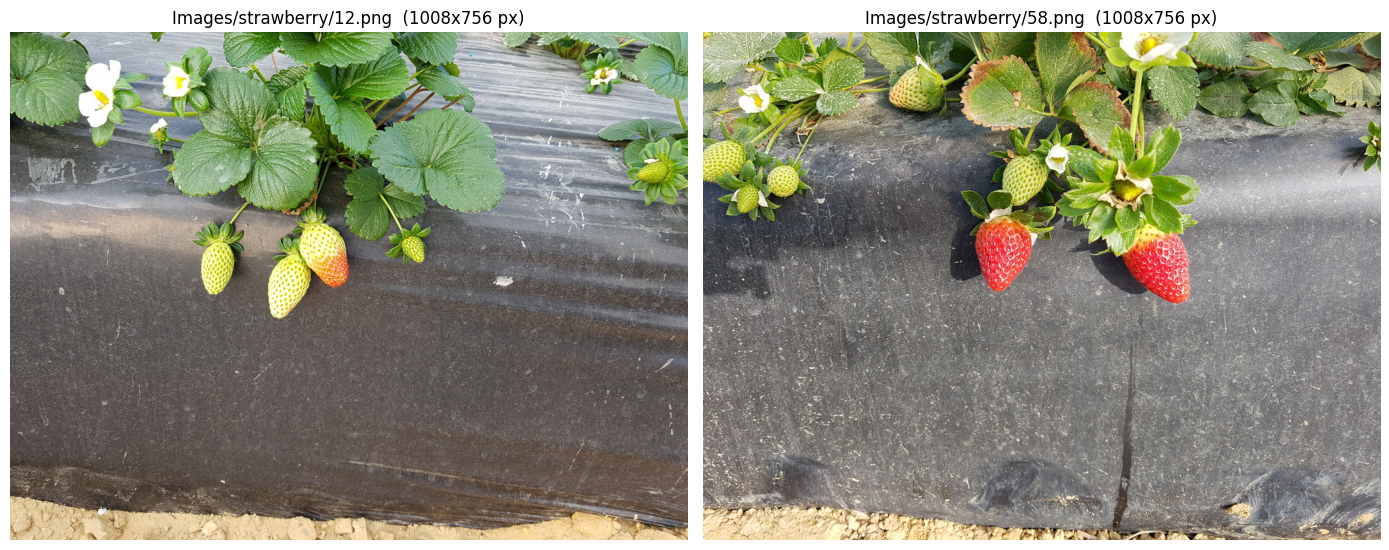

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, name in zip(axes, ['12', '58']):
    img = Image.open(f'/content/SDM-D/{name}.png')
    ax.imshow(img)
    ax.set_title(f'Images/strawberry/{name}.png  ({img.size[0]}x{img.size[1]} px)')
    ax.axis('off')
plt.tight_layout(); plt.show()

## Build the SDM models (author defaults)

Build SAM2 with the exact `SDM.py` settings — `SAM2AutomaticMaskGenerator(sam2, points_per_side=32, min_mask_region_area=50)` with config `sam2_hiera_l.yaml` — and OpenCLIP ViT-B-32 (`laion2b_s34b_b79k`), the checkpoint/key pair quoted in the SDM-D README. Two justified adaptations, following the author's own hardware guards: the global CUDA bf16 autocast in `SDM.py` and its TF32 flags are applied **only on compute capability ≥ 8.0** (T4 is SM 7.5, where bf16 has no tensor-core support); OpenCLIP runs on CPU exactly as in the authors' code (its input tensors are never moved to CUDA in `SDM.py`).

SDM.py と同一設定で SAM2 と OpenCLIP を構築します。bf16 autocast / TF32 は著者コードのハードウェア判定に従い SM 8.0 以上でのみ有効化します（T4 では無効）。

In [ ]:
import sys, torch
sys.path.insert(0, '/content/SDM-D')
from utils import (filter_masks_by_overlap, seg_describe_matching,
                   load_descriptions, make_mask_color_visualization_image)
sam2 = build_sam2('sam2_hiera_l.yaml', '/content/SDM-D/sam2_hiera_large.pt',
                  device='cuda', apply_postprocessing=False)
mask_generator = SAM2AutomaticMaskGenerator(sam2, points_per_side=32, min_mask_region_area=50)
clip_model, _, clip_preprocessor = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k')
clip_model.eval()
props = torch.cuda.get_device_properties(0)
if props.major >= 8:  # author SDM.py behaviour, guarded exactly like its TF32 check
    torch.autocast(device_type='cuda', dtype=torch.bfloat16).__enter__()
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
print('SAM2 mask generator and OpenCLIP ViT-B-32 ready; bf16 autocast:', props.major >= 8)
texts, labels, label_dict = load_descriptions('/content/SDM-D/straw_des.txt')
print('prompt classes (id -> label):', label_dict)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

SAM2 mask generator and OpenCLIP ViT-B-32 ready; bf16 autocast: False
prompt classes (id -> label): {'ripe': 0, 'unripe': 1, 'leaf': 2, 'stem': 3, 'flower': 4, 'others': 5}


## Single-image SDM glue function (AI-generated, author functions inside)

`SDM.py` is a folder-batch CLI, while its defaults define the method: grid prompting (32/row), Mask NMS at overlap ratio 0.9 keeping the higher SAM2 `stability_score`, and CLIP label assignment via the author's `seg_describe_matching`. This glue function applies exactly those author functions, in the author's order, to one image. The CLIP prompts come from the authors' `straw_des.txt` loaded above; the 'others' background label is included there by the authors.

SDM.py の既定値と著者関数をそのまま用いて、1 枚の画像を処理する薄いグルーコードです（AI 生成部分）。

In [ ]:
import time, cv2

def sdm_pseudo_label(png_path):
    """Run the paper's training-free SDM on one image with SDM.py defaults.
    Returns (rgb_image, kept_masks, bbox_results, yolo_label_lines)."""
    image = cv2.cvtColor(cv2.imread(png_path), cv2.COLOR_BGR2RGB)
    t0 = time.time()
    anns = mask_generator.generate(image)              # SAM2 32x32 grid prompting
    t_amg = time.time() - t0
    anns = sorted(anns, key=lambda x: x['area'], reverse=True)
    kept = filter_masks_by_overlap(anns, 0.9)          # author Mask NMS (utils.py)
    descriptions = [[t, l] for t, l in zip(texts, labels)]
    masks, bbox, seg = seg_describe_matching(          # author CLIP matching (utils.py)
        image, kept, descriptions, clip_preprocessor, clip_model, mask_color=True)
    print(f'{png_path}: {len(anns)} masks in {t_amg:.1f} s -> '
          f'{len(kept)} after Mask NMS -> {len(seg)} YOLO label lines')
    return image, masks, bbox, seg

## Run SDM on example 12.png

Execute the full training-free pipeline on the first example: expect roughly a hundred to a few hundred candidate masks from the 1024-point grid, deduplicated by Mask NMS, then each region classified by OpenCLIP against the strawberry prompts (or 'others').

最初の例画像 12.png に対し、SAM2 グリッド→Mask NMS→OpenCLIP 照合の一連を実行します。

In [ ]:
image12, masks12, bbox12, seg12 = sdm_pseudo_label('/content/SDM-D/12.png')

/usr/local/lib/python3.13/dist-packages/sam2/sam2_image_predictor.py:431: UserWarning: inputs.is_cuda() INTERNAL ASSERT FAILED at "sam2/csrc/connected_components.cu":215, please report a bug to PyTorch. inputs must be a CUDA tensor
Exception raised from get_connected_componnets at sam2/csrc/connected_components.cu:215 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9d (0x78bdfc77305d in /usr/local/lib/python3.13/dist-packages/torch/lib/libc10.so)
frame #1: c10::detail::torchCheckFail(char const*, char const*, unsigned int, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&) + 0xc3 (0x78bdfc7076fd in /usr/local/lib/python3.13/dist-packages/torch/lib/libc10.so)
frame #2: c10::detail::torchInternalAssertFail(char const*, char const*, unsigned int, char const*, char const*) + 0x42 (0x78bdfc76f6a2 in /usr/local/lib/python3.13/dist-packages/torch

/content/SDM-D/12.png: 55 masks in 8.7 s -> 41 after Mask NMS -> 41 YOLO label lines


## Visualization: input with SDM pseudo-label overlay

Render the original image next to the SDM result — colored pseudo-label masks (ripe/unripe/leaf/stem/flower per the authors' color scheme in `utils.py`; 'others' skipped) plus bounding boxes and class names. This overlay is the pipeline's actual output for this input, not a paper figure.

入力画像と、SDM の擬似ラベル（色付きマスク＋ボックス）の重ね合わせを表示します。著者 utils.py の配色に従います。

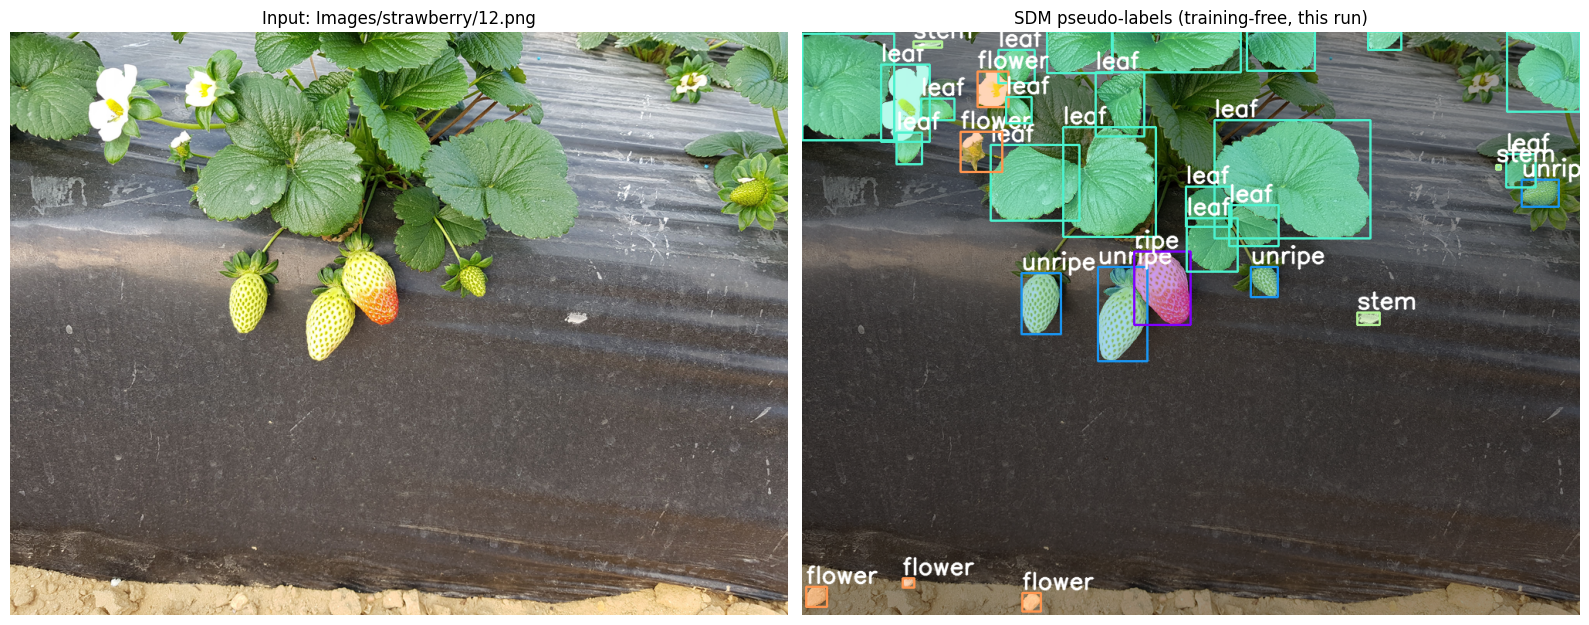

In [ ]:
vis = make_mask_color_visualization_image(image12, masks12, bbox12, label_dict,
                                          alpha=0.4, visualize_others=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(image12); axes[0].set_title('Input: Images/strawberry/12.png'); axes[0].axis('off')
axes[1].imshow(vis)
axes[1].set_title('SDM pseudo-labels (training-free, this run)'); axes[1].axis('off')
plt.tight_layout(); plt.savefig('/content/SDM-D/sdm_overlay_12.png', dpi=90, bbox_inches='tight')
plt.show()

## YOLO instance-segmentation labels

Write the pseudo-labels in the authors' YOLO polygon format (one line per instance: `class_id x1 y1 x2 y2 …`, coordinates normalized to image size, exactly as `seg_describe_matching` emits) to the output layout used by `SDM.py`, and summarize the instance counts per class.

YOLO ポリゴン形式の擬似ラベルを SDM.py と同じ出力レイアウトに保存し、クラス別インスタンス数を集計します。

In [ ]:
import os
out_label_dir = '/content/SDM-D/output/strawberry/labels/straw'
os.makedirs(out_label_dir, exist_ok=True)
with open(f'{out_label_dir}/12.txt', 'w') as f:
    f.writelines(seg12)
print(f'{out_label_dir}/12.txt — first 2 lines (truncated):')
for line in seg12[:2]:
    parts = line.split()
    print(' ', parts[0], ' '.join(parts[1:9]) + f' ... ({len(parts) - 1} coords)')
import collections, pandas as pd
id_to_label = {v: k for k, v in label_dict.items()}
counts = collections.Counter(id_to_label[int(l.split()[0])] for l in seg12)
print(pd.DataFrame(sorted(counts.items()), columns=['label', 'instances']))

/content/SDM-D/output/strawberry/labels/straw/12.txt — first 2 lines (truncated):
  2 0.665675 0.353175 0.666667 0.353175 0.667659 0.353175 0.668651 0.353175 ... (1056 coords)
  2 0.056548 0.185185 0.057540 0.185185 0.058532 0.185185 0.059524 0.185185 ... (858 coords)
    label  instances
0  flower          5
1    leaf         19
2  others          9
3    ripe          1
4    stem          3
5  unripe          4


## Convert to object-detection labels (authors' seg2det.py)

Convert the instance polygons to YOLO detection boxes with the authors' `convert_coords_to_bbox` from `seg2label/seg2det.py`. The function definition is extracted verbatim with `ast` because the script's module-level demo call contains the authors' hard-coded personal paths and would crash on import — the function body itself is unmodified.

著者の seg2det.py から関数を ast で取り出し（スクリプト直下のハードコードされた実行呼び出しを避けるため）、そのまま実行して検出ラベルへ変換します。

In [ ]:
import ast, os, pathlib
src = pathlib.Path('/content/SDM-D/seg2det.py').read_text()
fn = next(n for n in ast.parse(src).body
          if isinstance(n, ast.FunctionDef) and n.name == 'convert_coords_to_bbox')
ns = {'os': os}
exec(compile(ast.Module(body=[fn], type_ignores=[]), 'seg2det', 'exec'), ns)
ns['convert_coords_to_bbox']('/content/SDM-D/output/strawberry/labels', '/content/SDM-D/output/det')
det_path = '/content/SDM-D/output/det/straw/12.txt'
print('---', det_path, '(first 3 lines) ---')
print(''.join(pathlib.Path(det_path).read_text().splitlines(keepends=True)[:3]))

转换完成。
--- /content/SDM-D/output/det/straw/12.txt (first 3 lines) ---
2 0.6294645 0.2526455 0.19940500000000005 0.20105900000000002
2 0.0585315 0.0945765 0.117063 0.181217
2 0.394345 0.257275 0.11805600000000005 0.18650799999999998



## Second example 58.png and comparison with the authors' shipped reference

Run the identical pipeline on `58.png` and compare against the authors' shipped reference labels (`output/strawberry/labels/straw/58.txt`, generated by the authors from these same inputs). Reported per image: instance counts, class-id sequence agreement, per-line polygon point-count agreement, and — for lines with equal point counts — the mean absolute difference of matched polygon coordinates. Version differences between the authors' environment and this runtime can legitimately change mask sets, so this is a consistency check, not a bit-exactness requirement.

2 枚目の 58.png にも同一パイプラインを実行し、著者同梱の参照ラベルと整合性を比較します。

In [ ]:
import numpy as np

def parse_label_file(path):
    out = []
    for line in pathlib.Path(path).read_text().splitlines():
        p = line.split()
        out.append((int(p[0]), np.array([float(v) for v in p[1:]])))
    return out

def compare(name, ours):
    ref = parse_label_file(f'/content/SDM-D/ref_{name}.txt')
    cls_ok = sum(a[0] == b[0] for a, b in zip(ours, ref))
    pc_ok = sum(len(a[1]) == len(b[1]) for a, b in zip(ours, ref))
    diffs = [np.abs(a[1] - b[1]).mean() for a, b in zip(ours, ref) if len(a[1]) == len(b[1])]
    return dict(image=name, ours=len(ours), reference=len(ref),
                class_id_matches=cls_ok, point_count_matches=pc_ok,
                mean_poly_absdiff=(float(np.mean(diffs)) if diffs else None))

image58, masks58, bbox58, seg58 = sdm_pseudo_label('/content/SDM-D/58.png')
ours58 = [(int(l.split()[0]), np.array([float(v) for v in l.split()[1:]])) for l in seg58]
print(pd.DataFrame([compare('58', ours58)]).to_string(index=False))

/usr/local/lib/python3.13/dist-packages/sam2/sam2_image_predictor.py:431: UserWarning: inputs.is_cuda() INTERNAL ASSERT FAILED at "sam2/csrc/connected_components.cu":215, please report a bug to PyTorch. inputs must be a CUDA tensor
Exception raised from get_connected_componnets at sam2/csrc/connected_components.cu:215 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9d (0x78bdfc77305d in /usr/local/lib/python3.13/dist-packages/torch/lib/libc10.so)
frame #1: c10::detail::torchCheckFail(char const*, char const*, unsigned int, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&) + 0xc3 (0x78bdfc7076fd in /usr/local/lib/python3.13/dist-packages/torch/lib/libc10.so)
frame #2: c10::detail::torchInternalAssertFail(char const*, char const*, unsigned int, char const*, char const*) + 0x42 (0x78bdfc76f6a2 in /usr/local/lib/python3.13/dist-packages/torch

/content/SDM-D/58.png: 73 masks in 6.1 s -> 63 after Mask NMS -> 63 YOLO label lines
image  ours  reference  class_id_matches  point_count_matches  mean_poly_absdiff
   58    63         54                32                    1           0.000006


## Results summary and CSV export

Summarize both examples (instances per class for each image, plus the reference comparison) and export a small CSV next to the labels. This demonstrates that SDM produces the paper's outputs — instance masks, YOLO labels, detection boxes — on the repository's own example, training-free.

両画像のクラス別インスタンス数と参照比較をまとめ、CSV に出力します。

In [ ]:
counts58 = collections.Counter(id_to_label[int(l.split()[0])] for l in seg58)
summary = pd.DataFrame([
    {'image': '12.png', **{c: counts.get(c, 0) for c in sorted(id_to_label.values())}},
    {'image': '58.png', **{c: counts58.get(c, 0) for c in sorted(id_to_label.values())}},
])
print(summary.to_string(index=False))
summary.to_csv('/content/SDM-D/output/sdm_summary.csv', index=False)
print('saved: /content/SDM-D/output/sdm_summary.csv')

 image  flower  leaf  others  ripe  stem  unripe
12.png       5    19       9     1     3       4
58.png       4    44       3     2     3       7
saved: /content/SDM-D/output/sdm_summary.csv


## Interpretation, differences from the paper, and validation record

- **Executed scope:** training-free SDM pseudo-labeling on the authors' two strawberry examples with the authors' prompts, defaults (32/row grid, Mask NMS 0.9, min area 50, ViT-B-32/laion2b_s34b_b79k), and output formats — instance polygons, YOLO labels, detection boxes — plus a consistency comparison against the authors' shipped reference labels.
- **Not executed / out of scope:** MegaFruits dataset-level benchmarks, Mask-NMS ablations, SDM-D student distillation and few-shot fine-tuning, OVD baselines, Jetson benchmarks.
- **Adaptations:** single-image glue (AI-generated) around verbatim author functions; bf16 autocast/TF32 gated on SM ≥ 8.0 following the author's own hardware check (T4 is SM 7.5); `seg2det.py` function extracted via `ast` to skip the script's hard-coded demo call; CLIP on CPU as in `SDM.py`.
- **Expected variation:** SAM2/OpenCLIP library versions on this runtime differ from the authors' environment, so the mask set and some class assignments may differ from the shipped reference; the comparison cell reports the measured agreement rather than assuming equality.
- **Provenance:** all data and weights were downloaded inside this Colab VM from the pinned commit `0b73215…` and Meta's documented checkpoint URL; no dataset or weight bytes touched any local machine.

**日本語:** 本ノートブックは論文の教師不要 SDM を著者同梱の 2 枚のイチゴ例画像に実行した部分的なデモです。MegaFruits ベンチマーク・蒸留学習・少数ラベル再学習は対象外で、参照ラベルとの比較は環境差を考慮した整合性確認です。

**Sources:** arXiv:2411.16196v2 ([HTML](https://arxiv.org/html/2411.16196v2)) · [SDM-D repo @ 0b73215](https://github.com/AgRoboticsResearch/SDM-D/tree/0b73215ad49398b67074a385d6d9ca6b05638622) · [SAM2 checkpoint](https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt)